# Task1 仿真平台调用引擎的有效性


## 参考运行结果

直接调用 QuTiP/QuantumOptics/QuantumToolbox 等软件的参考代码，不通过 qsim 的仿真平台

In [1]:
import subprocess, json, sys
from pathlib import Path

REFERENCE_DIR = Path("task1\\native_references") 
JULIA_BIN = "julia"
JULIA_SYSIMG = Path("C:\\Users\\yijia\\.julia\\environments\\v1.12\\sysimage_quantum.dll")

def run_reference(cmd):
    return json.loads(subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", check=True).stdout)

res_refs = {}

res_refs["qutip"] = run_reference(
    [sys.executable, f"{REFERENCE_DIR}\\qutip_native.py"]
)
res_refs["qoptics"] = run_reference(
    [JULIA_BIN, "-J", JULIA_SYSIMG, f"{REFERENCE_DIR}\\qoptics_native.jl"]
)
res_refs["qtoolbox"] = run_reference(
    [JULIA_BIN, "-J", JULIA_SYSIMG, f"{REFERENCE_DIR}\\qtoolbox_native.jl"]
)


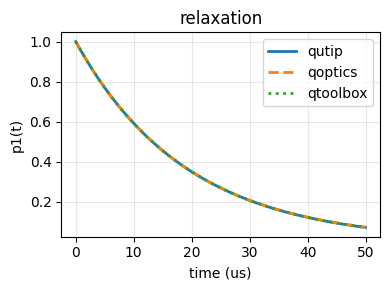

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 3))
ax = plt.axes()

styles = ["-", "--", ":"]
case_name = "relaxation"

for (engine_name, payload), style in zip(res_refs.items(), styles):
    case = payload["cases"][case_name]
    ax.plot(
        case["times"], case["p1_t"], 
        label=engine_name, linewidth=2, linestyle=style,
    )

    ax.set_title(case_name)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("p1(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## 调用 qsim

通过 qsim，调用三个引擎，进行同样的仿真模拟

In [6]:
from qsim.workflow import run_task_files
from pathlib import Path

TASK_DIR = Path("task1")

out_qutip = run_task_files(
    task_config=f"{TASK_DIR}\\task.yaml",
    solver_config=f"{TASK_DIR}\\qutip.yaml",
)
out_qoptics = run_task_files(
    task_config   = f"{TASK_DIR}\\task.yaml",
    solver_config = f"{TASK_DIR}\\qoptics.yaml",
)
out_qtoolbox = run_task_files(
    task_config   = f"{TASK_DIR}\\task.yaml",
    solver_config = f"{TASK_DIR}\\qtoolbox.yaml",
)

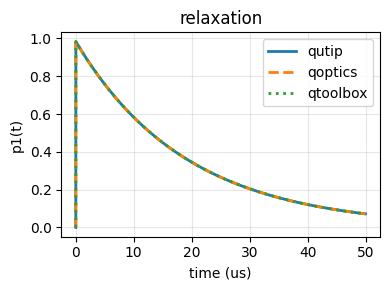

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(4, 3))
ax = plt.axes()

styles = ["-", "--", ":"]
case_name = "relaxation"

for out, style in zip([out_qutip, out_qoptics, out_qtoolbox], styles):
    t  = out['results']['metrics']['population']['times']
    p1 = out['results']['metrics']['population']['series']['1']
    engine_name = out['inputs']['solver']['engine']
    ax.plot(
        1e6 * np.array(t), np.array(p1),
        label=engine_name, linewidth=2, linestyle=style)

    ax.set_title(case_name)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("p1(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()